# Inertia-Corrected Newton Method for Equality Constrained NLPs


```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 1 rewritten markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

Background:

![Eqn5-12](https://raw.githubusercontent.com/ndcbe/optimization/main/media/eqn5-12.png)

The Algorithm:

![Alg5-2a](https://raw.githubusercontent.com/ndcbe/optimization/main/media/alg5-2a.png)

![Alg5-2b](https://raw.githubusercontent.com/ndcbe/optimization/main/media/alg5-2b.png)

## Helper Functions

In [1]:
# Load required Python libraries.
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg


## Check if element of array is NaN
def check_nan(A):
    return np.sum(np.isnan(A))


## Calculate gradient with central finite difference
def my_grad_approx(x, f, eps1, verbose=False):
    """
    Calculate gradient of function f using central difference formula

    Inputs:
        x - point for which to evaluate gradient
        f - function to consider
        eps1 - perturbation size

    Outputs:
        grad - gradient (vector)
    """

    n = len(x)
    grad = np.zeros(n)

    if verbose:
        print("***** my_grad_approx at x = ", x, "*****")

    for i in range(0, n):

        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps1

        # Finite difference formula
        my_f_plus = f(x + e)
        my_f_minus = f(x - e)

        # Diagnostics
        if verbose:
            print("e[", i, "] = ", e)
            print("f(x + e[", i, "]) = ", my_f_plus)
            print("f(x - e[", i, "]) = ", my_f_minus)

        grad[i] = (my_f_plus - my_f_minus) / (2 * eps1)

    if verbose:
        print("***** Done. ***** \n")

    return grad


def my_jac_approx(x, h, eps1, verbose=False):
    """
    Calculate Jacobian of function h(x) using central difference formula

    Inputs:
        x - point for which to evaluate gradient
        h - vector-valued function to consider. h(x): R^n --> R^m
        eps1 - perturbation size

    Outputs:
        A - Jacobian (n x m matrix)
    """

    # Check h(x) at x
    h_x0 = h(x)

    # Extract dimensions
    n = len(x)
    m = len(h_x0)

    # Initialize Jacobian matrix
    A = np.zeros((n, m))

    # Calculate Jacobian by row
    for i in range(0, n):

        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps1

        # Finite difference formula
        my_h_plus = h(x + e)
        my_h_minus = h(x - e)

        # Diagnostics
        if verbose:
            print("e[", i, "] = ", e)
            print("h(x + e[", i, "]) = ", my_h_plus)
            print("h(x - e[", i, "]) = ", my_h_minus)

        A[i, :] = (my_h_plus - my_h_minus) / (2 * eps1)

    if verbose:
        print("***** Done. ***** \n")

    return A


## Calculate gradient using central finite difference and my_hes_approx
def my_hes_approx(x, grad, eps2):
    """
    Calculate gradient of function my_f using central difference formula and my_grad

    Inputs:
        x - point for which to evaluate gradient
        grad - function to calculate the gradient
        eps2 - perturbation size (for Hessian NOT gradient approximation)

    Outputs:
        H - Hessian (matrix)
    """

    n = len(x)
    H = np.zeros([n, n])

    for i in range(0, n):
        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps2

        # Evaluate gradient twice
        grad_plus = grad(x + e)
        grad_minus = grad(x - e)

        # Notice we are building the Hessian by column (or row)
        H[:, i] = (grad_plus - grad_minus) / (2 * eps2)

    return H


## Linear algebra calculation
def xxT(u):
    """
    Calculates u*u.T to circumvent limitation with SciPy

    Arguments:
    u - numpy 1D array

    Returns:
    u*u.T

    Assume u is a nx1 vector.
    Recall: NumPy does not distinguish between row or column vectors

    u.dot(u) returns a scalar. This function returns an nxn matrix.
    """

    n = len(u)
    A = np.zeros([n, n])
    for i in range(0, n):
        for j in range(0, n):
            A[i, j] = u[i] * u[j]

    return A


## Analyze Hessian
def analyze_hes(B):
    print(B, "\n")

    l = linalg.eigvals(B)
    print("Eigenvalues: ", l, "\n")

## Algorithm 5.2

In [2]:
def assemble_check_KKT(W, A, deltaA, deltaW, verbose):

    n = np.size(W, 0)

    if np.size(W, 1) != n:
        print("WARNING: W is not square. Something is broken.")

    rA = np.size(A, 0)
    m = np.size(A, 1)

    if rA != n:
        print("WARNING: A does not have the correct number of rows.")

    # Assemble KKT matrix
    KKT_top = np.concatenate((W + deltaW * np.eye(n), A), axis=1)
    KKT_bot = np.concatenate((A.T, -deltaA * np.eye(m)), axis=1)
    KKT = np.concatenate((KKT_top, KKT_bot), axis=0)

    # Check inertia of KKT matrix.
    # Out of simplicity, we will just calculate the eigenvalues.
    # Biegler, 2010 explains a more sophisticated (and computationally efficient)
    # strategy
    l, eigvec = linalg.eig(KKT)

    zero_tol = 1e-12

    # Count number of positive eigenvalues
    pos_ev = sum(l >= zero_tol)

    # Count number of eigenvalues close to zero
    zero_ev = sum(np.abs(l) < zero_tol)

    # Count number of negative eigenvalues
    neg_ev = sum(l <= -zero_tol)

    inertia_correct = n == pos_ev and m == neg_ev

    if verbose:
        print(
            "deltaA = ",
            deltaA,
            "  deltaW = ",
            deltaW,
            "inertia =(",
            pos_ev,
            ",",
            neg_ev,
            ",",
            zero_ev,
            ")\n",
        )

    return KKT, inertia_correct, pos_ev, neg_ev, zero_ev


def alg52(x0, calc_f, calc_h, eps1=1e-6, eps2=1e-6, max_iter=10, verbose=False):
    """
    Basic Full Space Newton Method for Equality Constrained NLP

    Input:
        x0 - starting point (vector)
        calc_f - function to calculate objective (returns scalar)
        calc_h - function to calculate constraints (returns vector)
        eps1 - tolerance for primal and dual steps
        eps2 - tolerance for gradient of L1

    Outputs:
        x - history of steps (primal variables)
        v - history of steps (dual variables)
        f - history of objective evaluations
        h - history of constraint evaluations
        df - history of objective gradients
        dL - history of Lagrange function gradients
        A - history of constraint Jacobians
        W - history of Lagrange Hessians

    Notes:
        1. For simplicity, central finite difference is used
           for all gradient calculations.
    """

    ### Specifics for Algorithm 5.2
    # Tuning parameters
    delta_bar_W_min = 1e-20
    delta_bar_W_0 = 1e-4
    delta_bar_W_max = 1e40
    delta_bar_A = 1e-8
    kappa_u = 8
    kappa_l = 1 / 3

    # Declare iteration histories as empty lists
    x = []
    v = []
    f = []
    L = []
    h = []
    df = []
    dL = []
    A = []
    W = []

    # Set for first iteration
    delta_A = 0.0
    delta_W = 0.0
    delta_W_last = 0.0

    # Flag for iterations
    flag = True

    # Iteration counter
    k = 0

    # Copy initial point to primal variable history
    n = len(x0)
    x.append(x0)

    # Evaluate objective and constraints at initial point
    f.append(calc_f(x0))
    h.append(calc_h(x0))

    # Determine number of equality constraints
    m = len(h[0])

    # Initial dual variables with vector of ones
    v.append(np.ones(m))

    # Print header for iteration information
    print(
        "Iter. \tf(x) \t\t||h(x)|| \t||grad_L(x)|| \t||dx|| \t\t||dv|| \t\tdelta_A \tdelta_W"
    )

    while flag and k < max_iter:

        # STEP 1. Construct KKT matrix

        if k > 0:
            # Evaluate objective function
            f.append(calc_f(x[k]))

            # Evaluate constraint function
            h.append(calc_h(x[k]))

        # Evaluate objective gradient
        df.append(my_grad_approx(x[k], calc_f, 1e-6))

        # Evaluate constraint Jacobian
        A.append(my_jac_approx(x[k], calc_h, 1e-6))

        # Evaluate gradient of Lagrange function
        L_func = lambda x_: calc_f(x_) + (calc_h(x_)).dot(v[k])
        L_grad = lambda x_: my_grad_approx(x_, L_func, 1e-6)
        dL.append(L_grad(x[k]))
        norm_dL = linalg.norm(dL[k])

        # Evaluate Hessian of Lagrange function
        W.append(my_hes_approx(x[k], L_grad, 1e-6))

        if verbose:
            print("*** k =", k, " ***")
            print("x_k =", x[k])
            print("v_k =", v[k])
            print("f_k =", f[k])
            print("df_k =", df[k])
            print("h_k =", h[k])
            print("A_k =\n", A[k])
            print("W_k =\n", W[k])
            print("\n")

        ######
        # Algorithm 5.2: Add inertia correction to Algorithm 5.1

        ### ALG. 5.2, STEP 1
        delta_A = 0
        delta_W = 0

        KKT, inertia_correct, pos_ev, neg_ev, zero_ev = assemble_check_KKT(
            W[k], A[k], delta_A, delta_W, verbose
        )

        if not inertia_correct:
            ### ALG. 5.2, STEP 2
            # Assume zero eigenvalue is from rank-deficient Jacobian.
            # Set delta_A to non-zero value
            if zero_ev != 0:
                delta_A = delta_bar_A

            ### ALG. 5.2, STEP 3
            if delta_W_last == 0:
                delta_W = delta_bar_W_0
            else:
                delta_W = max(delta_bar_W_min, kappa_l * delta_W_last)

        while (not inertia_correct) and flag:
            ### ALG. 5.2, STEP 4
            KKT, inertia_correct, pos_ev, neg_ev, zero_ev = assemble_check_KKT(
                W[k], A[k], delta_A, delta_W, verbose
            )

            ### ALG. 5.2, STEP 5
            if not inertia_correct:
                delta_W = kappa_u * delta_W

            ### ALG. 5.2, STEP 6
            if delta_W > delta_bar_W_max:
                flag = False
                print("Abort step computation. KKT matrix is severely ill-conditioned.")

        delta_W_last = delta_W

        ## STEP 2. Solve linear system.

        if flag:
            b = -np.concatenate((dL[k], h[k]), axis=0)
            z = linalg.solve(KKT, b)
        else:
            z = []

        ## STEP 3. Take step
        if flag:
            dx = z[0:n]
            dv = z[n : n + m]

            x.append(x[k] + dx)
            v.append(v[k] + dv)

            norm_dx = linalg.norm(dx)
            norm_dv = linalg.norm(dv)

        ## Print iteration information
        print(
            k,
            "  \t{0: 1.4e} \t{1:1.4e} \t{2:1.4e}".format(
                f[k], linalg.norm(h[k]), norm_dL
            ),
            end="",
        )

        if flag:
            print(" \t{0: 1.4e} \t{1: 1.4e}".format(norm_dx, norm_dv), end="")
        else:
            print(" \t -------  \t -------", end="")

        print(" \t{0: 1.4e} \t{1: 1.4e}".format(delta_A, delta_W), end="\n")

        # Increment counter
        k = k + 1

        ## Check convergence criteria
        if flag:
            flag = norm_dx > eps1 and norm_dv > eps1 and norm_dL > eps2

    if flag and k >= max_iter:
        print("Reached maximum number of iterations.")

    return x, v, f, h, df, dL, A, W

## Example Problem 2

(Where is Example Problem 1? We are using the same number scheme as the previous notebook.)

Consider:
$$\begin{align}\min_x \quad & x_1^2 + 2 x_2^2 \\
\mathrm{s.t.} \quad & x_1 + x_2 = 1 \\
 & x_1 + x_2 = 1 \end{align}$$

### Test Algorithm 5.2 with redundant constraints.

In [3]:
## Define functions
def my_f2(x):
    return x[0] ** 2 + 2 * x[1] ** 2


def my_h2(x):
    h = np.zeros(2)
    h[0] = x[0] + x[1] - 1
    h[1] = h[0]
    return h


## Declare initial point
x0 = np.array((1, 1))

## Run Algorithm 5.2 on test problem
results = alg52(x0, my_f2, my_h2, verbose=False)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv|| 		delta_A 	delta_W
0   	 3.0000e+00 	1.4142e+00 	7.2111e+00 	 7.4537e-01 	 2.3571e+00 	 1.0000e-08 	 1.0000e-04
1   	 6.6667e-01 	2.3373e-08 	2.9368e-04 	 5.4909e-05 	 9.4088e-05 	 1.0000e-08 	 3.3333e-05
2   	 6.6667e-01 	9.4080e-13 	2.0599e-09 	 5.8893e-10 	 2.3614e-10 	 1.0000e-08 	 1.1111e-05

x* = [0.66666667 0.33333333]

v* = [-0.66666667 -0.66666667]


### Test Algorithm 5.2 without redundant constraints.

In [4]:
## Define functions
def my_h2b(x):
    return (x[0] + x[1] - 1) * np.ones(1)


## Run Algorithm 5.2 on test problem
results = alg52(x0, my_f2, my_h2b, verbose=False)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv|| 		delta_A 	delta_W
0   	 3.0000e+00 	1.0000e+00 	5.8310e+00 	 7.4537e-01 	 2.3335e+00 	 0.0000e+00 	 0.0000e+00
1   	 6.6667e-01 	1.3978e-10 	2.9473e-04 	 4.5325e-05 	 1.5285e-04 	 0.0000e+00 	 0.0000e+00
2   	 6.6667e-01 	1.7764e-15 	2.8419e-09 	 7.9814e-10 	 5.1808e-10 	 0.0000e+00 	 0.0000e+00

x* = [0.66666667 0.33333333]

v* = [-1.33333333]


### Discussion

* Compare the multipliers with and without the redundant constraint.

## Example Problem 3

Let us try a model where $\nabla h(x^k)^T$ is full rank but there are multiple local optima.

Consider:
$$\begin{align}\min_x \quad & x_1^3 - x_2 -x_1 x_2 - x_2^2 \\
\mathrm{s.t.} \quad & x_1^2 + x_2^2 = 1
\end{align}$$

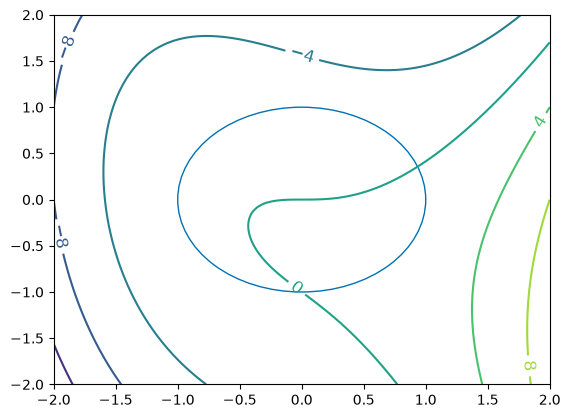

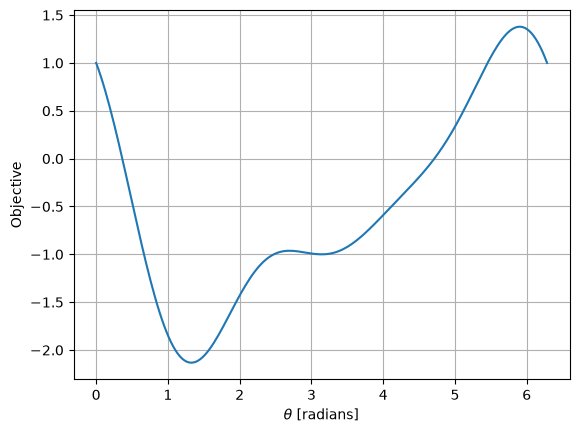

In [5]:
## Copied from notebook with Algorithm 5.1
def my_f3(x):
    return x[0] ** 3 - x[1] - x[0] * x[1] - x[1] ** 2


def my_h3(x):
    return (x[0] ** 2 + x[1] ** 2 - 1) * np.ones(1)


def visualize(xk=[]):
    n1 = 101
    n2 = 101
    x1eval = np.linspace(-2, 2, n1)
    x2eval = np.linspace(-2, 2, n2)

    X, Y = np.meshgrid(x1eval, x2eval)

    Z = np.zeros([n2, n1])

    for i in range(0, n1):
        for j in range(0, n2):
            Z[j, i] = my_f3((X[j, i], Y[j, i]))

    fig, ax = plt.subplots(1, 1)
    CS = ax.contour(X, Y, Z)
    ax.clabel(CS, inline=1, fontsize=12)

    # Add unit circle
    # Okabe-Ito blue (figures/dowling.mplstyle), was matplotlib's "b".
    circ = plt.Circle((0, 0), radius=1, edgecolor="#0072B2", facecolor="None")
    ax.add_patch(circ)

    # Plot iteration history
    if len(xk) > 0:
        for i in range(0, len(xk)):
            if i == len(xk) - 1:
                c = "#D55E00"  # Okabe-Ito vermillion: the final iterate
            else:
                c = "black"
            plt.scatter(
                (xk[i][0]),
                (xk[i][1]),
                marker="*" if i == len(xk) - 1 else "o",
                s=90 if i == len(xk) - 1 else 30,
                color=c,
            )

    plt.xlim([-2, 2])
    plt.ylim([-2, 2])


visualize()

nt = 200
theta = np.linspace(0, 2 * np.pi, nt)
obj = np.zeros(nt)


for i in range(0, nt):
    x_ = np.cos(theta[i])
    y_ = np.sin(theta[i])

    obj[i] = my_f3((x_, y_))


plt.figure()
plt.plot(theta, obj)
plt.xlabel("$\\theta$ [radians]")
plt.ylabel("Objective")
plt.grid()

### Starting Point Near Global Min ($\theta_0 = 1.0$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv|| 		delta_A 	delta_W
0   	-1.8465e+00 	0.0000e+00 	1.9015e+00 	 3.8312e-01 	 7.2367e-01 	 0.0000e+00 	 0.0000e+00
1   	-2.3659e+00 	1.4678e-01 	3.3718e-01 	 7.8768e-02 	 7.9620e-02 	 0.0000e+00 	 0.0000e+00
2   	-2.1425e+00 	6.2044e-03 	1.2116e-02 	 3.2309e-03 	 3.9114e-03 	 0.0000e+00 	 0.0000e+00
3   	-2.1324e+00 	1.0439e-05 	2.4821e-05 	 5.3713e-06 	 9.2590e-06 	 0.0000e+00 	 0.0000e+00
4   	-2.1323e+00 	2.8850e-11 	6.2804e-10 	 6.6450e-11 	 2.6422e-10 	 0.0000e+00 	 0.0000e+00

x* = [0.24215301 0.97023807]

v* = [1.64012794]

theta* = 1.3262120357381408 = 1.3262120357381406


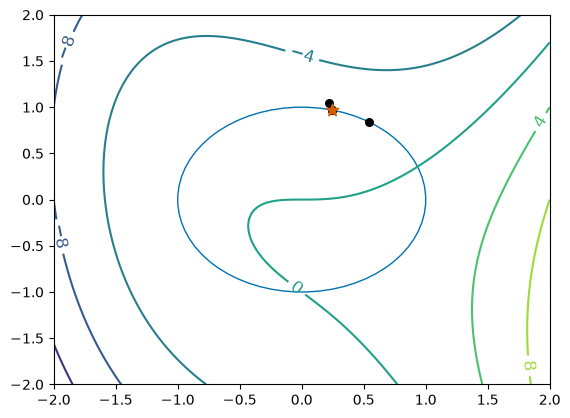

In [6]:
theta0 = 1.0
x0 = np.array((np.cos(theta0), np.sin(theta0)))

## Run Algorithm 5.2 on test problem
results = alg52(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "=", np.arcsin(xstar[1]))

## Visualize
visualize(results[0])

### Starting Point Near Local Min ($\theta_0 = \pi$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv|| 		delta_A 	delta_W
0   	-1.0000e+00 	0.0000e+00 	1.0000e+00 	 2.5001e-05 	 5.0001e-01 	 1.0000e-08 	 1.0000e-04
1   	-1.0000e+00 	5.6252e-09 	2.4999e-05 	 2.4999e-05 	 1.2503e-05 	 0.0000e+00 	 0.0000e+00
2   	-1.0000e+00 	6.2494e-10 	2.0651e-09 	 2.0023e-09 	 2.0682e-09 	 0.0000e+00 	 0.0000e+00

x* = [-1.00000000e+00  8.19937667e-11]

v* = [1.5]

theta* = 3.141592653589793 (using arccos)

theta* = 8.199376671710346e-11 (using arcsin)


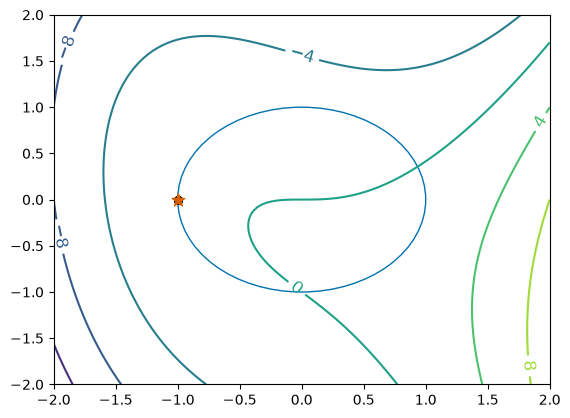

In [7]:
theta0 = np.pi
x0 = np.array((np.cos(theta0), np.sin(theta0)))

## Run Algorithm 5.2 on test problem
results = alg52(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "(using arccos)")
print("\ntheta* =", np.arcsin(xstar[1]), "(using arcsin)")

## Visualize
visualize(results[0])

### Starting Point Near Global Max ($\theta_0 = 5.5$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv|| 		delta_A 	delta_W
0   	 1.0637e+00 	0.0000e+00 	4.0116e+00 	 6.3909e-01 	 8.9136e-01 	 0.0000e+00 	 0.0000e+00
1   	 1.3218e-01 	4.0844e-01 	1.6281e+00 	 1.0969e+00 	 8.7287e-01 	 0.0000e+00 	 0.0000e+00
2   	-1.8894e+00 	1.2033e+00 	1.6888e+00 	 5.3584e-01 	 6.8040e-01 	 0.0000e+00 	 3.2768e+00
3   	-1.1341e+00 	2.8713e-01 	1.0279e+00 	 7.0356e-01 	 9.4021e-02 	 0.0000e+00 	 0.0000e+00
4   	-1.8391e+00 	4.9500e-01 	2.7810e-01 	 2.0378e-01 	 2.2458e-01 	 0.0000e+00 	 0.0000e+00
5   	-1.0630e+00 	4.1526e-02 	3.4498e-02 	 3.6578e-02 	 2.9119e-02 	 0.0000e+00 	 0.0000e+00
6   	-1.0020e+00 	1.3380e-03 	1.8083e-03 	 2.5371e-03 	 2.2187e-03 	 0.0000e+00 	 0.0000e+00
7   	-1.0000e+00 	6.4371e-06 	1.0840e-05 	 1.4321e-05 	 1.2544e-05 	 0.0000e+00 	 0.0000e+00
8   	-1.0000e+00 	2.0510e-10 	1.5464e-09 	 1.5493e-09 	 1.2043e-09 	 0.0000e+00 	 0.0000e+00

x* = [-1.00000000e+00  9.94196533e-11]

v* = [1.5]

theta* = 3.141592653589793 (using ar

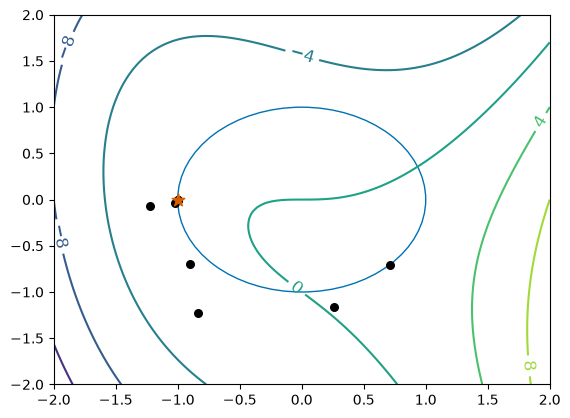

In [8]:
theta0 = 5.5
x0 = np.array((np.cos(theta0), np.sin(theta0)))

## Run Algorithm 5.2 on test problem
results = alg52(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "(using arccos)")
print("\ntheta* =", np.arcsin(xstar[1]), "(using arcsin)")

## Visualize
visualize(results[0])